In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/fesavaskurt/Python&ML/Kodlarım/Python/datasets/ML Datasets/car_data.csv")

In [3]:
df.head()

,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0


In [5]:
df.shape

(1000, 5)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User ID       1000 non-null   int64 
 1   Gender        1000 non-null   object
 2   Age           1000 non-null   int64 
 3   AnnualSalary  1000 non-null   int64 
 4   Purchased     1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


In [8]:
df.isnull().sum()

User ID         0
Gender          0
Age             0
AnnualSalary    0
Purchased       0
dtype: int64

In [9]:
df.nunique()

User ID         1000
Gender             2
Age               46
AnnualSalary     247
Purchased          2
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["Purchased"].value_counts()

Purchased
0    598
1    402
Name: count, dtype: int64

<Axes: xlabel='Purchased', ylabel='count'>

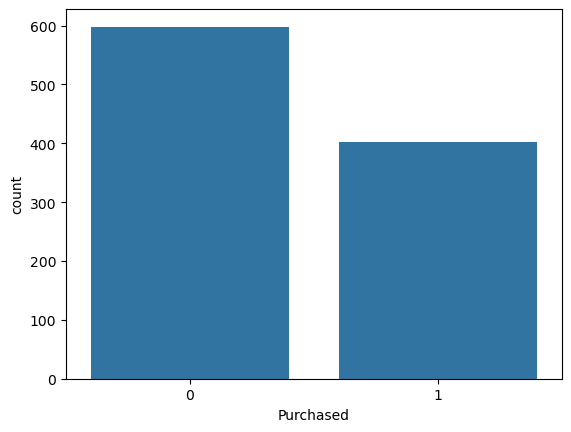

In [16]:
sns.barplot(df["Purchased"].value_counts())

<Axes: xlabel='Purchased', ylabel='count'>

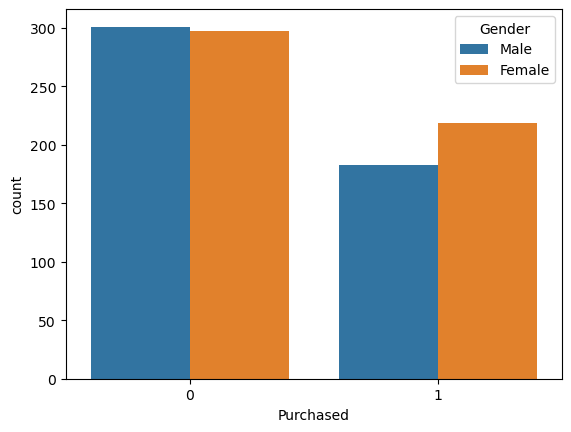

In [25]:
sns.countplot(data=df, x="Purchased", hue="Gender")

In [26]:
df.groupby("Gender")["Purchased"].mean()

Gender
Female    0.424419
Male      0.378099
Name: Purchased, dtype: float64

In [20]:
df_clean = df.drop("User ID", axis=1)

In [21]:
df_clean.head()

,Gender,Age,AnnualSalary,Purchased
0,Male,35,20000,0
1,Male,40,43500,0
2,Male,49,74000,0
3,Male,40,107500,1
4,Male,25,79000,0


In [30]:
df_clean = pd.get_dummies(df_clean, columns=["Gender"], drop_first= True)

In [31]:
from sklearn.model_selection import train_test_split

In [49]:
df_clean["Purchased"]

0      0
1      0
2      0
3      1
4      0
      ..
995    0
996    0
997    1
998    1
999    0
Name: Purchased, Length: 1000, dtype: int64

In [52]:
X = df_clean.drop(["Purchased"], axis=1)
y = df_clean["Purchased"]

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state= 42, test_size= 0.2
)

In [55]:
from sklearn.tree import DecisionTreeClassifier

In [56]:
model = DecisionTreeClassifier()

In [57]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [58]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [59]:
print("score: ", accuracy_score(y_pred, y_test))
print("matrix: ", confusion_matrix(y_pred, y_test))
print("classification: ", classification_report(y_pred, y_test))

score:  0.9
matrix:  [[104  12]
 [  8  76]]
classification:                precision    recall  f1-score   support

           0       0.93      0.90      0.91       116
           1       0.86      0.90      0.88        84

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



In [61]:
model.score(X_train, y_train)


0.995

In [62]:
model.score(X_test, y_test)

0.9